In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt
from numba import njit
import numpy as np

Text(0.5, 1.0, 'Original PPG')

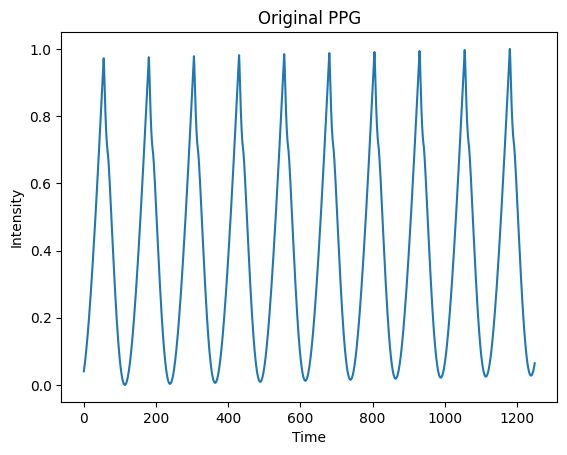

In [3]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      solver="rk3")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

In [4]:
# Define custom cost function
@njit
def custom_cost(model, signal):
    cost = np.sum((model - signal)**2)
    return cost

In [7]:
# Extract signal parameters
# pass custom cost function as parameter in ppgExtractor
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=3,
                      basis_type='gamma',
                      solver="rk3",
                      cost_func=custom_cost,
                      cost_metrics=[])

/home/aju/Desktop/key_repos/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: cost_weights parameter is invalid (None), defaulting to [1, 1]
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


In [8]:
ppgExt.cost_metrics = ["mse", "corr"]
theta_pred, params_pred = ppgExt.extract_ppg(block_update=True, 
                                             coord_cycles=4)

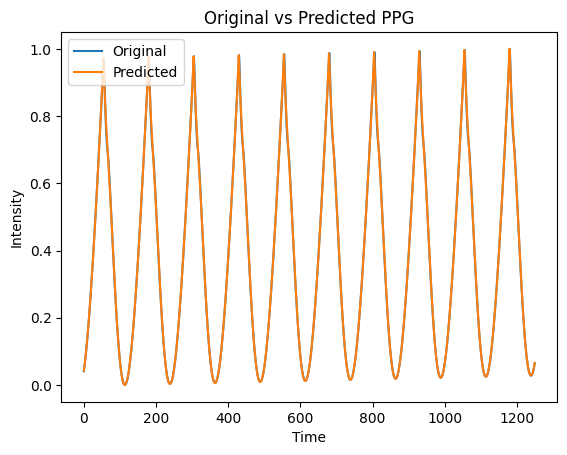

In [10]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      thetas=theta_pred,
                      params=params_pred,
                      solver="rk3")
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted"])